# Matplotlib on Datasets

In [21]:
import pandas as pd 
import matplotlib .pyplot as plt

In [22]:
df=pd.read_csv("C:\\Users\\ywako\\Downloads\\matplotlib_sales_clean_1000 - matplotlib_sales_clean_1000.csv")
df

,Order_ID,Order_Date,City,Product_Category,Customer_Segment,Customer_Age,Units_Sold,Unit_Price,Discount_Pct,Customer_Rating,Gross_Sales,Discount_Amount,Revenue,Cost,Profit
0,ORD00849,2025-01-01,Pune,Home & Kitchen,Budget,36,5,13359.07,2.33,3.4,66795.35,1556.33,65239.02,45347.81,19891.21
1,ORD00678,2025-01-01,Hyderabad,Home & Kitchen,Premium,42,2,13594.04,19.92,3.9,27188.08,5415.87,21772.21,15198.49,6573.72
2,ORD00649,2025-01-01,Delhi,Home & Kitchen,Budget,25,5,1657.67,2.85,2.7,8288.35,236.22,8052.13,4569.99,3482.14
3,ORD00756,2025-01-01,Bengaluru,Home & Kitchen,Premium,31,3,2487.88,32.94,3.7,7463.64,2458.52,5005.12,3547.03,1458.09
4,ORD00992,2025-01-01,Delhi,Beauty,Regular,43,4,20911.12,26.06,4.2,83644.48,21797.75,61846.73,36979.40,24867.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,ORD00720,2025-12-31,Chennai,Sports,Budget,49,5,9489.48,9.73,2.7,47447.40,4616.63,42830.77,31699.40,11131.37
996,ORD00619,2025-12-31,Pune,Beauty,Budget,35,3,19429.79,30.38,2.9,58289.37,17708.31,40581.06,30770.88,9810.18
997,ORD00313,2025-12-31,Chennai,Electronics,Regular,30,2,18361.89,23.31,2.9,36723.78,8560.31,28163.47,21513.83,6649.64
998,ORD00420,2025-12-31,Pune,Electronics,Regular,22,4,11116.13,25.97,4.0,44464.52,11547.44,32917.08,26150.54,6766.54


####  1. Plot monthly Revenue as a line chart. Add title, axis labels, markers, grid, and legend.

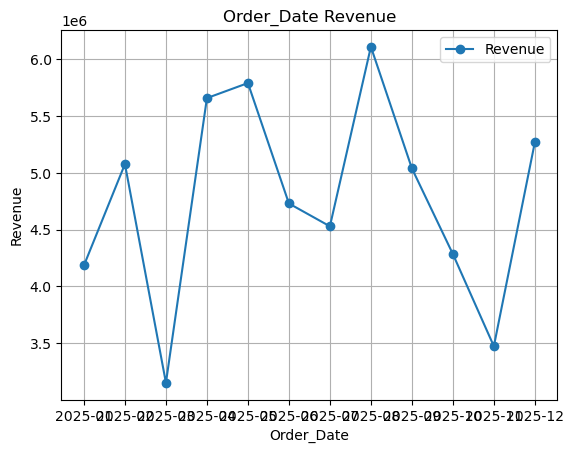

In [23]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])
monthly_revenue = df.groupby(
    df["Order_Date"].dt.to_period("M")
)["Revenue"].sum()
plt.plot(
    monthly_revenue.index.astype(str),
    monthly_revenue.values,
    marker="o",
    label="Revenue")
plt.title("Order_Date Revenue")
plt.xlabel("Order_Date")
plt.ylabel("Revenue")
plt.grid(True)
plt.legend()
plt.show()

#### 2. Plot monthly Revenue and Profit on the same chart using different line styles.

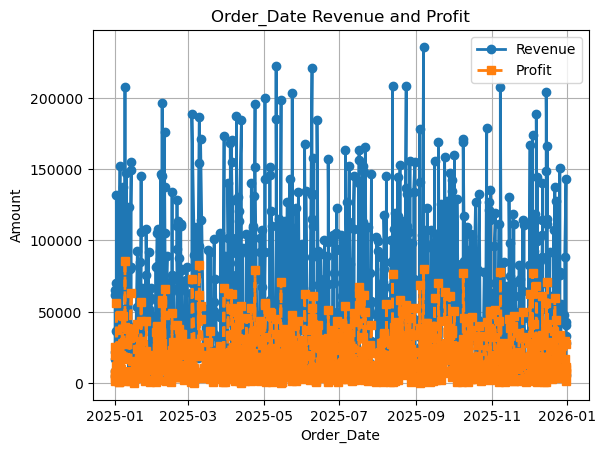

In [24]:
plt.plot(df["Order_Date"], df["Revenue"],
         linestyle="-",
         marker="o",
         linewidth=2,
         label="Revenue")

plt.plot(df["Order_Date"], df["Profit"],
         linestyle="--",
         marker="s",
         linewidth=2,
         label="Profit")
plt.title("Order_Date Revenue and Profit")
plt.xlabel("Order_Date")
plt.ylabel("Amount")
plt.legend()
plt.grid(True)
plt.show()

#### 3. Create a bar chart of total Revenue by Product_Category and sort the categories from highest to lowest revenue.

Product_Category
Sports            13006511.99
Beauty            12563940.72
Clothing          11735728.79
Electronics       11513555.37
Home & Kitchen     8484162.57
Name: Revenue, dtype: float64


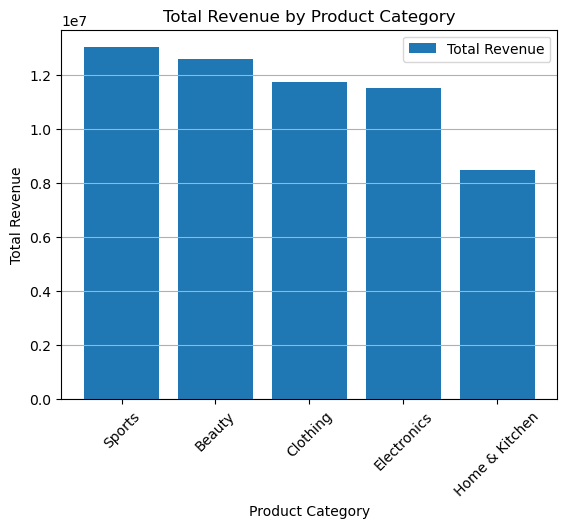

In [25]:
category_revenue = (
    df.groupby("Product_Category")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

print(category_revenue)

plt.bar(
    category_revenue.index,
    category_revenue.values,
    label="Total Revenue"
)
plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis="y")
plt.show()

#### 4. Create a bar chart of total Profit by City and highlight the city with the highest profit.

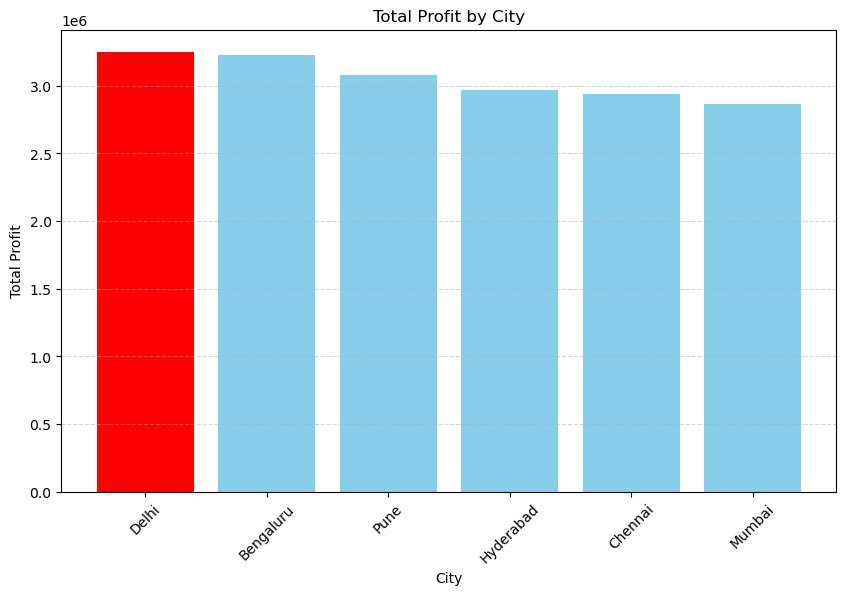

Highest Profit City: Delhi


In [26]:
city_profit = df.groupby("City")["Profit"].sum().sort_values(ascending=False)

highest_city = city_profit.idxmax()

colors = ["red" if city == highest_city else "skyblue"
          for city in city_profit.index]

plt.figure(figsize=(10, 6))
plt.bar(city_profit.index, city_profit.values, color=colors)

plt.title("Total Profit by City")
plt.xlabel("City")
plt.ylabel("Total Profit")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()
print("Highest Profit City:", highest_city)

#### 5. Create a horizontal bar chart showing the top 10 orders based on Revenue.

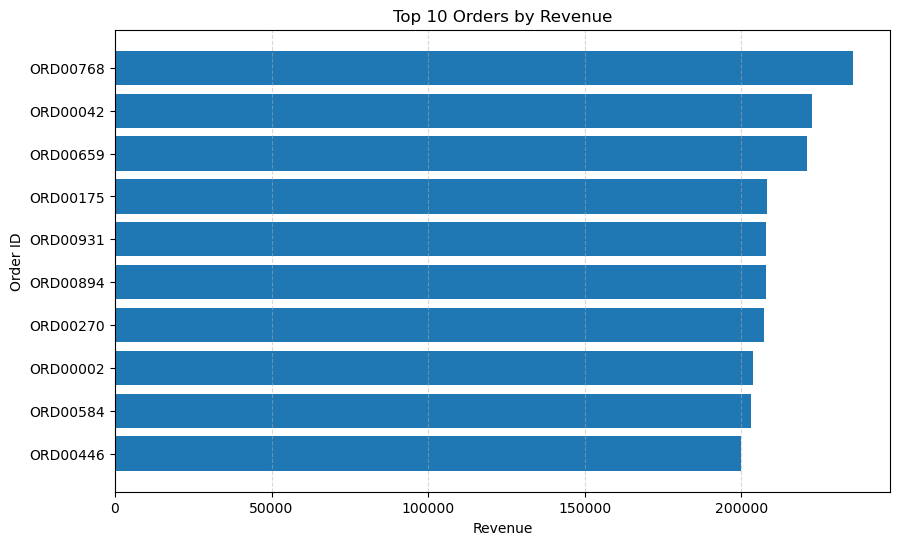

In [31]:
top_10 = df.nlargest(10, "Revenue")

plt.figure(figsize=(10, 6))
plt.barh(top_10["Order_ID"].astype(str), top_10["Revenue"])

plt.title("Top 10 Orders by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Order ID")
plt.gca().invert_yaxis()
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.show()

#### 6. Create a histogram of Customer_Age using 10 appropriate bins. Add mean and median lines.

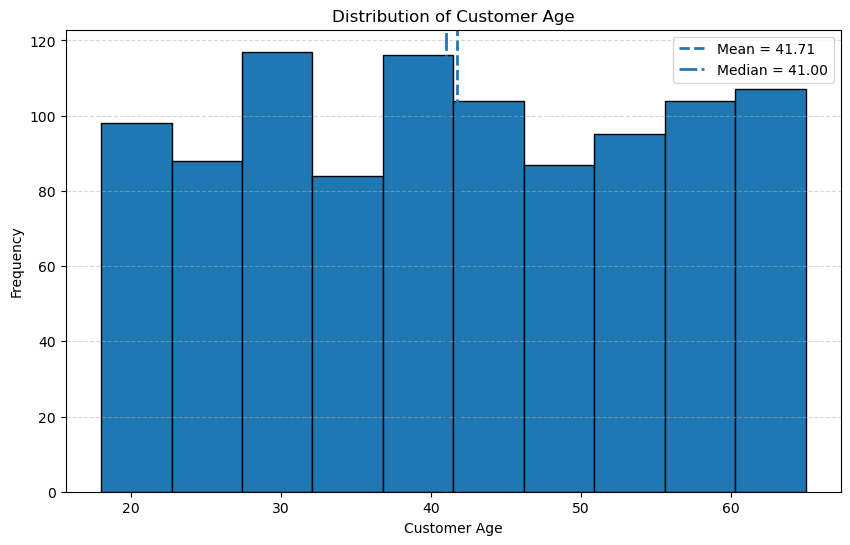

In [29]:
mean_age = df["Customer_Age"].mean()
median_age = df["Customer_Age"].median()
plt.figure(figsize=(10, 6))
plt.hist(df["Customer_Age"], bins=10, edgecolor="black")
plt.axvline(mean_age, linestyle="--", linewidth=2,
            label=f"Mean = {mean_age:.2f}")
plt.axvline(median_age, linestyle="-.", linewidth=2,
            label=f"Median = {median_age:.2f}")
plt.title("Distribution of Customer Age")
plt.xlabel("Customer Age")
plt.ylabel("Frequency")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

#### 7. Create a histogram of Revenue and explain visually whether the distribution appears symmetric or skewed.

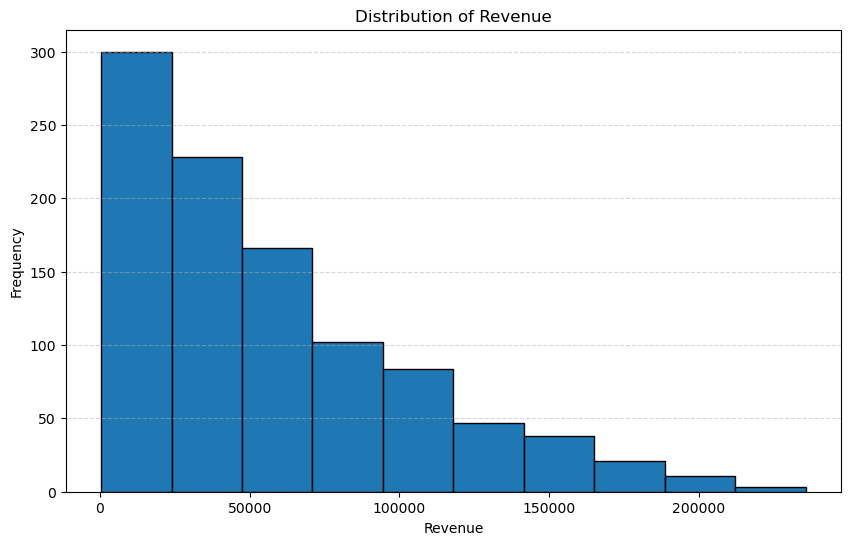

In [30]:
plt.figure(figsize=(10, 6))
plt.hist(df["Revenue"], bins=10, edgecolor="black")
plt.title("Distribution of Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

#### 8. Create a scatter plot of Unit_Price vs Units_Sold. Use different marker sizes based on Revenue.

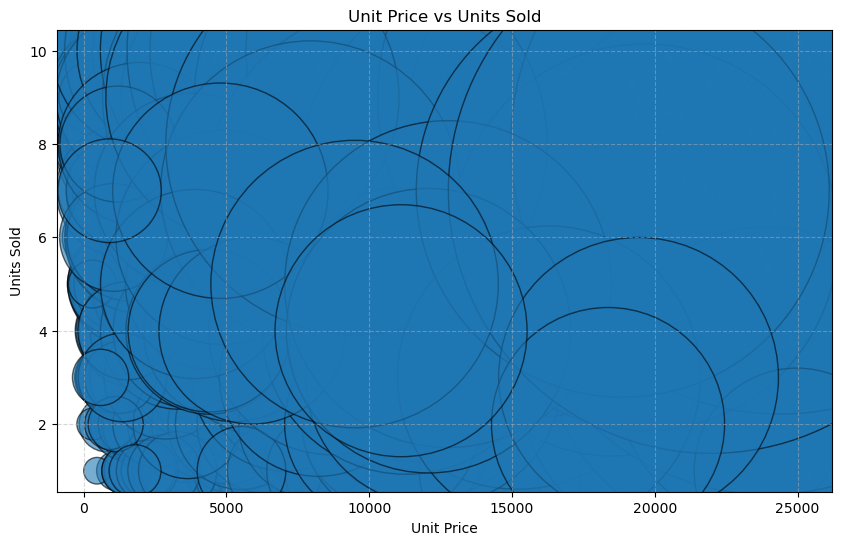

In [33]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Unit_Price"],
    df["Units_Sold"],
    s=df["Revenue"],       
    alpha=0.6,
    edgecolor="black"
)
plt.title("Unit Price vs Units Sold")
plt.xlabel("Unit Price")
plt.ylabel("Units Sold")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#### 9. Create a scatter plot of Discount_Pct vs Profit and determine visually whether higher discounts are associated with lower profit.

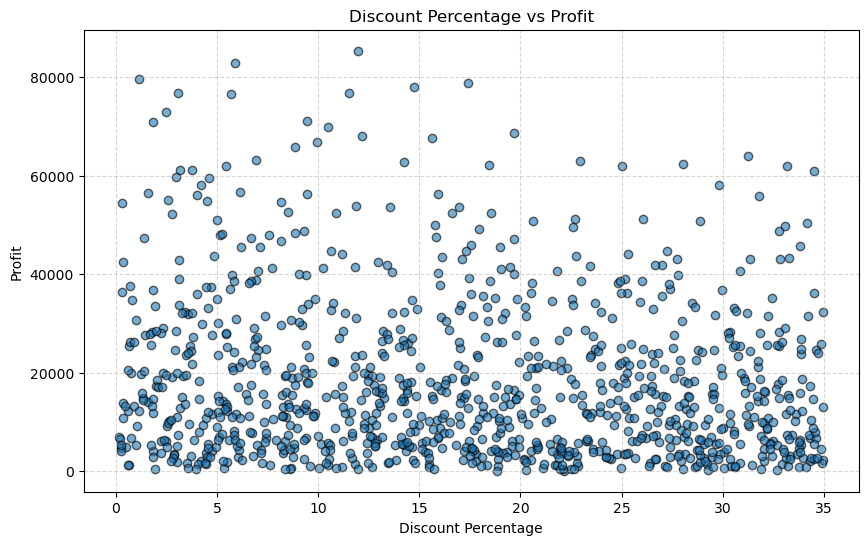

In [34]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["Discount_Pct"],
    df["Profit"],
    alpha=0.6,
    edgecolor="black"
)
plt.title("Discount Percentage vs Profit")
plt.xlabel("Discount Percentage")
plt.ylabel("Profit")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

#### 10. Create a scatter plot of Revenue vs Profit and highlight the five orders having the highest profit.

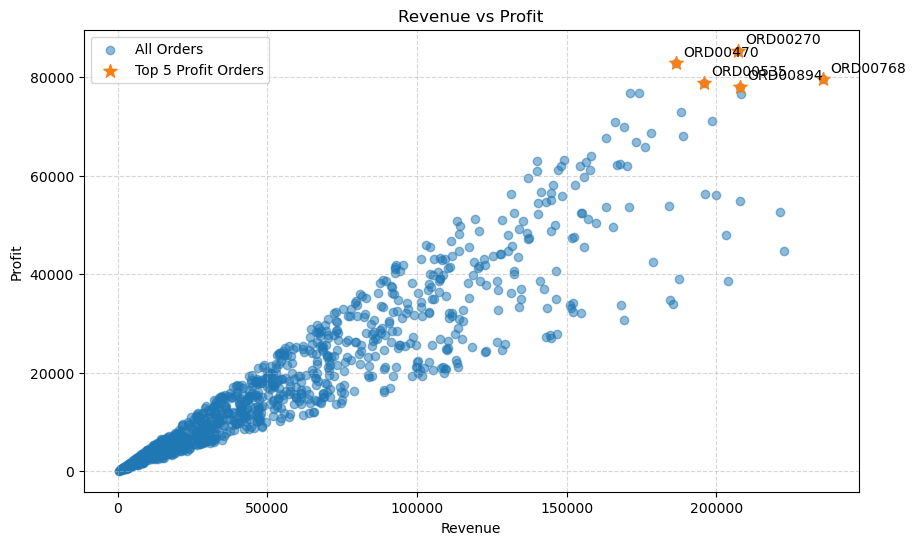

In [35]:
# Get the 5 orders with highest profit
top_5 = df.nlargest(5, "Profit")
plt.figure(figsize=(10, 6))
plt.scatter(
    df["Revenue"],
    df["Profit"],
    alpha=0.5,
    label="All Orders"
)
plt.scatter(
    top_5["Revenue"],
    top_5["Profit"],
    s=100,
    marker="*",
    label="Top 5 Profit Orders"
)
for _, row in top_5.iterrows():
    plt.annotate(
        str(row["Order_ID"]),
        (row["Revenue"], row["Profit"]),
        xytext=(5, 5),
        textcoords="offset points"
    )
plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()